# StyleGAN2 Sonar Domain Adaptation Pipeline
**Synthetic → Real Sonar Transfer Learning + Dataset Augmentation**



---
**Prerequisites:** NVIDIA GPU with ≥8 GB VRAM, CUDA 11+, Python 3.8+

## Cell 1 — Install Dependencies

In [1]:
# Install StyleGAN2-ADA-PyTorch (NVIDIA's recommended fork)
import subprocess, sys, platform, os

def run(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print('STDERR:', result.stderr[-2000:])
    else:
        print(result.stdout[-500:])

# ── Detect OS and set clone path ──────────────────────────────────
if platform.system() == 'Windows':
    SG2_DIR = os.path.join(os.environ.get('USERPROFILE', 'C:\\Users\\user'), 'stylegan2')
else:
    SG2_DIR = '/tmp/stylegan2'

if not os.path.isdir(SG2_DIR):
    print('Cloning StyleGAN2-ADA (this takes ~30s)...')
    result = subprocess.run(
        f'git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git "{SG2_DIR}"',
        shell=True, capture_output=True, text=True
    )
    print(result.stderr)  # git writes progress to stderr — normal
    if result.returncode != 0:
        print('ERROR:', result.stdout)
else:
    print(f'Already cloned: {SG2_DIR}')
assert os.path.isfile(os.path.join(SG2_DIR, 'dataset_tool.py')), 'Clone failed — dataset_tool.py not found!'
sys.path.insert(0, SG2_DIR)
print(f'✅ StyleGAN2 path: {SG2_DIR}')

# Core dependencies
run('pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118')
run('pip install -q numpy pillow scipy requests tqdm matplotlib seaborn scikit-image lpips click')
run('pip install -q ninja')  # needed for CUDA custom ops

print('✅ Dependencies installed')

Already cloned: C:\Users\T1_Machine\stylegan2
✅ StyleGAN2 path: C:\Users\T1_Machine\stylegan2



✅ Dependencies installed


## Cell 2 — Configuration

In [2]:
import os
from pathlib import Path

# ─────────────────────────────────────────────────
# USER CONFIG — edit these paths
# ─────────────────────────────────────────────────

# Your real sonar images (any resolution, JPG/PNG, as many as you have)
REAL_SONAR_DIR   = './SIM2REAL/real/'         # ← point to your real sonar images
SYNTH_SONAR_DIR  = './SIM2REAL/fake/'    # ← your synthetic seabed objects dataset

# StyleGAN2 repo path (auto-set in Cell 1, but can override here)
import platform
if 'SG2_DIR' not in dir():
    if platform.system() == 'Windows':
        SG2_DIR = os.path.join(os.environ.get('USERPROFILE', 'C:\\Users\\user'), 'stylegan2')
    else:
        SG2_DIR = '/tmp/stylegan2'

# Output directories
OUT_DIR          = Path('./stylegan2_output')
DATASET_DIR      = OUT_DIR / 'dataset_prepared'
CHECKPOINT_DIR   = OUT_DIR / 'checkpoints'
GENERATED_DIR    = OUT_DIR / 'generated'
AUGMENTED_DIR    = OUT_DIR / 'augmented_dataset'
STATS_DIR        = OUT_DIR / 'stats'

for d in [OUT_DIR, DATASET_DIR, CHECKPOINT_DIR, GENERATED_DIR, AUGMENTED_DIR, STATS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Training config
RESOLUTION       = 256          # 64 / 128 / 256 / 512 / 1024
BATCH_SIZE       = 8            # reduce to 4 if OOM on 8 GB GPU
N_KIMG_FINETUNE  = 200          # kimg of fine-tuning (200–1000 is typical)
TRANSFER_PRESET  = 'auto'       # 'auto' | 'stylegan2' — ADA picks best augmentation
NUM_GENERATE     = 500          # novel images to sample after training
TRUNCATION_PSI   = 0.7          # 0.5=conservative, 1.0=full diversity

# Pretrained network to start from
# Best starting points for sonar-like textures:
#   'https://api.ngc.nvidia.com/v2/models/nvidia/research/stylegan2_ada/versions/1/files/paper256.pkl'  (FFHQ-256, good textures)
#   'https://api.ngc.nvidia.com/v2/models/nvidia/research/stylegan2_ada/versions/1/files/afhqwild512.pkl' (wildlife, grainy textures)
PRETRAINED_URL   = 'https://api.ngc.nvidia.com/v2/models/nvidia/research/stylegan2_ada/versions/1/files/afhqwild512.pkl'
PRETRAINED_PATH  = str(CHECKPOINT_DIR / 'pretrained.pkl')

print(f'Resolution:  {RESOLUTION}x{RESOLUTION}')
print(f'Fine-tune:   {N_KIMG_FINETUNE} kimg  (~{N_KIMG_FINETUNE*1000//BATCH_SIZE:,} steps)')
print(f'Generate:    {NUM_GENERATE} novel images')
print('Config ✅')

Resolution:  256x256
Fine-tune:   200 kimg  (~25,000 steps)
Generate:    500 novel images
Config ✅


## Cell 3 — GPU Check

In [4]:
import torch

assert torch.cuda.is_available(), '❌ No GPU detected! Check CUDA install.'

gpu = torch.cuda.get_device_properties(0)
print(f'✅ GPU: {gpu.name}')
print(f'   VRAM: {gpu.total_memory / 1e9:.1f} GB')
print(f'   CUDA: {torch.version.cuda}')

if gpu.total_memory < 6e9:
    print('⚠️  < 6 GB VRAM: lower RESOLUTION to 128 or BATCH_SIZE to 4')

✅ GPU: NVIDIA RTX 4000 Ada Generation
   VRAM: 21.5 GB
   CUDA: 12.4


## Cell 4 — Prepare Dataset (convert to StyleGAN2 ZIP format)

In [3]:
import shutil
from PIL import Image
import numpy as np

def preprocess_sonar(src_dir: str, dst_dir: Path, resolution: int):
    """
    Resize + normalize sonar images for StyleGAN2.
    Converts to grayscale→RGB (StyleGAN2 expects 3ch by default),
    applies CLAHE-like contrast enhancement common for sonar.
    """
    src = Path(src_dir)
    exts = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}
    images = [p for p in src.rglob('*') if p.suffix.lower() in exts]
    print(f'Found {len(images)} images in {src_dir}')

    dst_dir.mkdir(parents=True, exist_ok=True)
    for i, img_path in enumerate(images):
        img = Image.open(img_path).convert('L')           # sonar is grayscale
        img = img.resize((resolution, resolution), Image.LANCZOS)
        arr = np.array(img, dtype=np.float32)
        # Histogram stretch per-image (improves GAN training on low-contrast sonar)
        p2, p98 = np.percentile(arr, 2), np.percentile(arr, 98)
        if p98 > p2:
            arr = np.clip((arr - p2) / (p98 - p2) * 255, 0, 255)
        img_out = Image.fromarray(arr.astype(np.uint8)).convert('RGB')  # 3ch
        img_out.save(dst_dir / f'{i:06d}.png')

    print(f'  → Saved {len(images)} preprocessed images to {dst_dir}')
    return len(images)

# Preprocess real sonar images (these are what we fine-tune on)
real_prep_dir = DATASET_DIR / 'real_prep'
n_real = preprocess_sonar(REAL_SONAR_DIR, real_prep_dir, RESOLUTION)

print(f'\n📊 Real sonar images available for fine-tuning: {n_real}')
if n_real < 100:
    print('⚠️  < 100 images: ADA augmentation will compensate, but results may vary')
    print('   Tip: mirror/crop augment first to reach ≥ 100')
elif n_real < 500:
    print('ℹ️  100–500 images: good for ADA; expect solid results in ~200 kimg')
else:
    print('✅  500+ images: excellent for fine-tuning')

Found 938 images in ./SIM2REAL/real/
  → Saved 938 preprocessed images to stylegan2_output\dataset_prepared\real_prep

📊 Real sonar images available for fine-tuning: 938
✅  500+ images: excellent for fine-tuning


## Cell 5 — Convert to StyleGAN2 ZIP dataset

In [4]:
import subprocess

dataset_zip = str(DATASET_DIR / f'sonar_{RESOLUTION}.zip')

import os
dataset_tool = os.path.join(SG2_DIR, 'dataset_tool.py')
cmd = (
    f'python "{dataset_tool}" '
    f'--source={real_prep_dir} '
    f'--dest={dataset_zip} '
    
)
print('Running dataset_tool.py...')
result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
print(result.stdout[-1000:])
if result.returncode != 0:
    print('STDERR:', result.stderr[-1000:])
else:
    print(f'✅ Dataset ZIP created: {dataset_zip}')

Running dataset_tool.py...

✅ Dataset ZIP created: stylegan2_output\dataset_prepared\sonar_256.zip


## Cell 6 — Download Pretrained Weights

In [5]:
import requests
from tqdm.notebook import tqdm

def download_file(url, dest, chunk_size=1 << 20):
    if Path(dest).exists():
        print(f'Already exists: {dest}')
        return
    print(f'Downloading {url}...')
    resp = requests.get(url, stream=True)
    total = int(resp.headers.get('content-length', 0))
    with open(dest, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as pbar:
        for chunk in resp.iter_content(chunk_size=chunk_size):
            f.write(chunk)
            pbar.update(len(chunk))
    print(f'✅ Saved to {dest}')

download_file(PRETRAINED_URL, PRETRAINED_PATH)

# If NGC download fails, alternative: use a local .pkl you already have
# PRETRAINED_PATH = '/path/to/your/network-snapshot.pkl'

Already exists: stylegan2_output\checkpoints\pretrained.pkl


## Cell 7 — Fine-Tune StyleGAN2-ADA on Real Sonar

In [7]:
import subprocess
import os
import subprocess
import warnings



# ... rest of your script setup
# ADA transfer learning: starts from pretrained, adapts to your sonar domain
# --cfg=paper256 matches 256px; use paper512 for 512, stylegan2 for 1024
# --kimg controls total training (200 = fast test, 1000 = high quality)

cfg_map = {64: 'paper64', 128: 'paper128', 256: 'paper256', 512: 'paper512', 1024: 'stylegan2'}
cfg = cfg_map.get(RESOLUTION, 'paper256')

import os
train_script = os.path.join(SG2_DIR, 'train.py')

train_cmd = (
    f'python "{train_script}" '
    f'--outdir={CHECKPOINT_DIR} '
    f'--data={dataset_zip} '
    f'--cfg={cfg} '
    f'--batch={BATCH_SIZE} '
    f'--kimg={N_KIMG_FINETUNE} '
    f'--resume={PRETRAINED_PATH} '
    f'--freezed=10 '          # freeze first 10 D layers → stabilises fine-tuning
    f'--aug=noaug '
    f'--mirror=1 '             # horizontal flip (sonar is often symmetric)
    f'--snap=20 '              # save checkpoint every 20 kimg
    f'--metrics=none'          # skip FID during training (speeds up run)
)

print('Starting fine-tuning...')
print(f'Command:\n{train_cmd}\n')
print('💡 Training progress appears in the terminal / output below.')
print('   Checkpoints saved every 20 kimg to:', CHECKPOINT_DIR)
print('   You can interrupt and resume — use --resume=<last .pkl>')
print()

# Stream output in real-time
process = subprocess.Popen(train_cmd, shell=True, stdout=subprocess.PIPE,
                           stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in process.stdout:
    print(line, end='', flush=True)
process.wait()

if process.returncode == 0:
    print('\n✅ Training complete!')
else:
    print(f'\n❌ Training exited with code {process.returncode}')

Starting fine-tuning...
Command:
python "C:\Users\T1_Machine\stylegan2\train.py" --outdir=stylegan2_output\checkpoints --data=stylegan2_output\dataset_prepared\sonar_256.zip --cfg=paper256 --batch=8 --kimg=200 --resume=stylegan2_output\checkpoints\pretrained.pkl --freezed=10 --aug=noaug --mirror=1 --snap=20 --metrics=none

💡 Training progress appears in the terminal / output below.
   Checkpoints saved every 20 kimg to: stylegan2_output\checkpoints
   You can interrupt and resume — use --resume=<last .pkl>


Training options:
{
  "num_gpus": 1,
  "image_snapshot_ticks": 20,
  "network_snapshot_ticks": 20,
  "metrics": [],
  "random_seed": 0,
  "training_set_kwargs": {
    "class_name": "training.dataset.ImageFolderDataset",
    "path": "stylegan2_output\\dataset_prepared\\sonar_256.zip",
    "use_labels": false,
    "max_size": 938,
    "xflip": true,
    "resolution": 256
  },
  "data_loader_kwargs": {
    "pin_memory": true,
    "num_workers": 3,
    "prefetch_factor": 2
  },
  "G_kw

## Cell 8 — Find Best Checkpoint

In [6]:
import glob

# List all saved checkpoints
ckpts = sorted(glob.glob(str(CHECKPOINT_DIR / '**' / 'network-snapshot-*.pkl'), recursive=True))
print(f'Found {len(ckpts)} checkpoints:')
for c in ckpts:
    print(f'  {c}')

# Use the latest checkpoint by default
# To use a specific one: BEST_CKPT = ckpts[N]
BEST_CKPT = ckpts[-1] if ckpts else PRETRAINED_PATH
print(f'\n→ Using checkpoint: {BEST_CKPT}')

Found 7 checkpoints:
  stylegan2_output\checkpoints\00004-sonar_256-mirror-paper256-kimg200-batch8-noaug-resumecustom-freezed10\network-snapshot-000000.pkl
  stylegan2_output\checkpoints\00005-sonar_256-mirror-paper256-kimg200-batch8-noaug-resumecustom-freezed10\network-snapshot-000000.pkl
  stylegan2_output\checkpoints\00006-sonar_256-mirror-paper256-kimg200-batch8-noaug-resumecustom-freezed10\network-snapshot-000000.pkl
  stylegan2_output\checkpoints\00007-sonar_256-mirror-paper256-kimg200-batch8-noaug-resumecustom-freezed10\network-snapshot-000000.pkl
  stylegan2_output\checkpoints\00007-sonar_256-mirror-paper256-kimg200-batch8-noaug-resumecustom-freezed10\network-snapshot-000080.pkl
  stylegan2_output\checkpoints\00007-sonar_256-mirror-paper256-kimg200-batch8-noaug-resumecustom-freezed10\network-snapshot-000160.pkl
  stylegan2_output\checkpoints\00007-sonar_256-mirror-paper256-kimg200-batch8-noaug-resumecustom-freezed10\network-snapshot-000200.pkl

→ Using checkpoint: stylegan2_out

## Cell 9 — W-Space Sampling: Generate Novel Sonar Images

In [7]:
import sys, os
if SG2_DIR not in sys.path:
    sys.path.insert(0, SG2_DIR)

import torch
import numpy as np
import pickle
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm

device = torch.device('cuda')

# Load fine-tuned generator
print(f'Loading network from {BEST_CKPT} ...')
with open(BEST_CKPT, 'rb') as f:
    G = pickle.load(f)['G_ema'].to(device)
G.eval()
print('✅ Generator loaded')
print(f'   W-space dim: {G.w_dim}  |  Z-space dim: {G.z_dim}')


def sample_wspace(G, n: int, psi: float = 0.7, seed: int = 42,
                  out_dir: Path = GENERATED_DIR):
    """
    Sample in W-space using truncation trick.
    psi < 1.0 → closer to average face (higher fidelity, less diversity)
    psi = 1.0 → full diversity
    Returns list of PIL images.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(seed)
    images = []

    # Compute W-space mean (centroid) for truncation
    with torch.no_grad():
        z_samples = torch.from_numpy(
            rng.standard_normal((10000, G.z_dim)).astype(np.float32)
        ).to(device)
        w_avg = G.mapping(z_samples, None).mean(0, keepdim=True)  # [1, w_dim]

    print(f'Generating {n} images at ψ={psi} ...')
    batch = 16
    for start in tqdm(range(0, n, batch)):
        bs = min(batch, n - start)
        z = torch.from_numpy(
            rng.standard_normal((bs, G.z_dim)).astype(np.float32)
        ).to(device)

        with torch.no_grad():
            w = G.mapping(z, None)                      # [bs, num_ws, w_dim]
            w_trunc = w_avg + psi * (w - w_avg)         # truncation
            imgs = G.synthesis(w_trunc, noise_mode='const')  # [-1, 1]

        imgs = (imgs.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).cpu().numpy().astype(np.uint8)
        for j, img_arr in enumerate(imgs):
            img = Image.fromarray(img_arr).convert('L').convert('RGB')  # keep grayscale look
            path = out_dir / f'gen_{start+j:06d}.png'
            img.save(path)
            images.append(img)

    print(f'✅ Saved {n} generated images to {out_dir}')
    return images


generated_images = sample_wspace(G, NUM_GENERATE, psi=TRUNCATION_PSI)

Loading network from stylegan2_output\checkpoints\00007-sonar_256-mirror-paper256-kimg200-batch8-noaug-resumecustom-freezed10\network-snapshot-000200.pkl ...
✅ Generator loaded
   W-space dim: 512  |  Z-space dim: 512
Setting up PyTorch plugin "bias_act_plugin"... 

C:\Users\T1_Machine\anaconda3\Lib\site-packages\torch\utils\cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Done.
Generating 500 images at ψ=0.7 ...


  0%|          | 0/32 [00:00<?, ?it/s]

Setting up PyTorch plugin "upfirdn2d_plugin"... 

C:\Users\T1_Machine\anaconda3\Lib\site-packages\torch\utils\cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Done.
✅ Saved 500 generated images to stylegan2_output\generated


## Cell 10 — W-Space Interpolation (optional: smooth transitions between sonar appearances)

In [ ]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

INTERP_STEPS = 10   # frames between two W-space seeds

def w_interpolate(G, seed_a: int, seed_b: int, steps: int = 10):
    """Linear interpolation between two points in W-space."""
    rng = np.random.default_rng
    def seed_to_w(seed):
        z = torch.from_numpy(np.random.default_rng(seed).standard_normal((1, G.z_dim)).astype(np.float32)).to(device)
        with torch.no_grad():
            return G.mapping(z, None)

    w_a = seed_to_w(seed_a)
    w_b = seed_to_w(seed_b)
    frames = []
    for t in np.linspace(0, 1, steps):
        w = (1 - t) * w_a + t * w_b
        with torch.no_grad():
            img_t = G.synthesis(w, noise_mode='const')
        arr = (img_t.permute(0,2,3,1)[0] * 127.5 + 128).clamp(0,255).cpu().numpy().astype(np.uint8)
        frames.append(Image.fromarray(arr))
    return frames

interp_frames = w_interpolate(G, seed_a=0, seed_b=999, steps=INTERP_STEPS)

fig, axes = plt.subplots(1, INTERP_STEPS, figsize=(INTERP_STEPS * 2, 2))
fig.suptitle('W-Space Interpolation: Seed A → Seed B', fontsize=12, y=1.02)
for ax, frame in zip(axes, interp_frames):
    ax.imshow(frame, cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.savefig(str(STATS_DIR / 'w_interpolation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Interpolation grid saved')

## Cell 11 — Assemble Augmented Dataset

In [14]:
import shutil
from pathlib import Path

# Three sources → one augmented dataset
sources = {
    'synthetic': (Path(SYNTH_SONAR_DIR), 'synth'),
    'real_sonar': (real_prep_dir,          'real'),
    'generated':  (GENERATED_DIR,          'gen'),
}

counts = {}
for label, (src, prefix) in sources.items():
    dst = AUGMENTED_DIR / label
    dst.mkdir(parents=True, exist_ok=True)
    exts = {'.png', '.jpg', '.jpeg', '.tif', '.bmp'}
    imgs = [p for p in src.rglob('*') if p.suffix.lower() in exts]
    for i, p in enumerate(imgs):
        shutil.copy(p, dst / f'{prefix}_{i:06d}.png')
    counts[label] = len(imgs)
    print(f'  {label:12s}: {len(imgs):5d} images → {dst}')

total = sum(counts.values())
print(f'\n✅ Augmented dataset assembled: {total} total images')
print(f'   Breakdown: synthetic={counts["synthetic"]} | real={counts["real_sonar"]} | generated={counts["generated"]}')

  synthetic   :   572 images → stylegan2_output\augmented_dataset\synthetic
  real_sonar  :   940 images → stylegan2_output\augmented_dataset\real_sonar
  generated   :   508 images → stylegan2_output\augmented_dataset\generated

✅ Augmented dataset assembled: 2020 total images
   Breakdown: synthetic=572 | real=940 | generated=508


## Cell 12 — Visual Comparison Grid

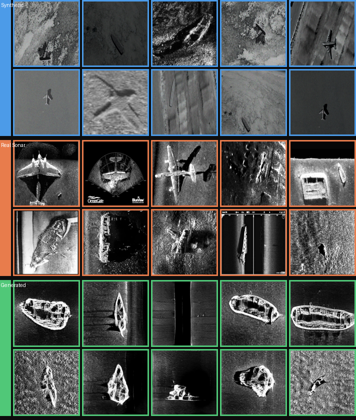

✅ Grid saved: stylegan2_output\stats\comparison_grid.png  (712×840px)


In [8]:
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path
import random, os
import numpy as np

ROWS_PER_SOURCE = 2
COLS = 5
THUMB = 128        # thumbnail size in pixels
BORDER = 3         # colored border thickness
GAP = 4            # gap between images
LABEL_H = 22       # height of left label strip

random.seed(42)

def load_thumbs(directory: Path, n: int):
    exts = {'.png', '.jpg', '.jpeg', '.tif'}
    paths = [p for p in directory.rglob('*') if p.suffix.lower() in exts]
    chosen = random.sample(paths, min(n, len(paths)))
    imgs = []
    for p in chosen:
        try:
            imgs.append(Image.open(p).convert('RGB').resize((THUMB, THUMB)))
        except Exception:
            pass
    return imgs

n_each = ROWS_PER_SOURCE * COLS
categories = [
    ('Synthetic',  load_thumbs(Path(SYNTH_SONAR_DIR), n_each), (76, 155, 232)),
    ('Real Sonar', load_thumbs(real_prep_dir,          n_each), (232, 124, 76)),
    ('Generated',  load_thumbs(GENERATED_DIR,          n_each), (80, 200, 120)),
]

cell_w = THUMB + BORDER * 2
cell_h = THUMB + BORDER * 2
total_w = LABEL_H + GAP + COLS * cell_w + (COLS - 1) * GAP
total_h = len(categories) * (ROWS_PER_SOURCE * cell_h + (ROWS_PER_SOURCE - 1) * GAP + GAP * 2)

canvas = Image.new('RGB', (total_w, total_h), color=(13, 13, 13))
draw = ImageDraw.Draw(canvas)

y_cursor = 0
for label, imgs, color in categories:
    # Draw vertical label strip
    label_strip = Image.new('RGB', (LABEL_H, ROWS_PER_SOURCE * cell_h + (ROWS_PER_SOURCE-1)*GAP), color)
    canvas.paste(label_strip, (0, y_cursor))

    idx = 0
    for row in range(ROWS_PER_SOURCE):
        for col in range(COLS):
            x = LABEL_H + GAP + col * (cell_w + GAP)
            y = y_cursor + row * (cell_h + GAP)
            # Colored border bg
            border_box = Image.new('RGB', (cell_w, cell_h), color)
            canvas.paste(border_box, (x, y))
            # Thumbnail
            if idx < len(imgs):
                canvas.paste(imgs[idx], (x + BORDER, y + BORDER))
                idx += 1
        
    y_cursor += ROWS_PER_SOURCE * cell_h + (ROWS_PER_SOURCE-1)*GAP + GAP*2

# Add text labels (try, fallback to no font if unavailable)
y_cursor = 0
for label, imgs, color in categories:
    try:
        draw.text((2, y_cursor + 4), label, fill=(255,255,255), font=None)
    except Exception:
        pass
    y_cursor += ROWS_PER_SOURCE * cell_h + (ROWS_PER_SOURCE-1)*GAP + GAP*2

grid_path = STATS_DIR / 'comparison_grid.png'
canvas.save(str(grid_path))

# Show inline at reduced size
display_img = canvas.resize((canvas.width // 2, canvas.height // 2))
display_img.save(str(STATS_DIR / 'comparison_grid_preview.png'))

from IPython.display import display as ipy_display
ipy_display(display_img)
print(f'✅ Grid saved: {grid_path}  ({canvas.width}×{canvas.height}px)')

## Cell 13 — Dataset Statistics

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
import random

def compute_stats(directory: Path, n_sample: int = 200, label: str = ''):
    """Compute per-image stats: mean intensity, std, contrast, sharpness proxy."""
    exts = {'.png', '.jpg', '.jpeg', '.tif'}
    all_imgs = [p for p in directory.rglob('*') if p.suffix.lower() in exts]
    sample = random.sample(all_imgs, min(n_sample, len(all_imgs)))

    means, stds, contrasts, sharpness = [], [], [], []
    for p in tqdm(sample, desc=label, leave=False):
        img = np.array(Image.open(p).convert('L'), dtype=np.float32)
        means.append(img.mean())
        stds.append(img.std())
        contrasts.append(img.max() - img.min())
        # Laplacian variance as sharpness proxy
        from scipy.ndimage import laplace
        sharpness.append(laplace(img).var())

    return {
        'n': len(all_imgs),
        'mean_intensity': np.array(means),
        'std_intensity': np.array(stds),
        'contrast': np.array(contrasts),
        'sharpness': np.array(sharpness),
    }

print('Computing dataset statistics...')
stats = {
    'Synthetic':   compute_stats(Path(SYNTH_SONAR_DIR),  label='Synthetic'),
    'Real Sonar':  compute_stats(real_prep_dir,           label='Real Sonar'),
    'Generated':   compute_stats(GENERATED_DIR,           label='Generated'),
}

# ── Print summary table ──
print(f"\n{'Source':<14} {'N':>6}  {'Mean':>7}  {'Std':>7}  {'Contrast':>9}  {'Sharpness':>10}")
print('─' * 60)
for name, s in stats.items():
    print(f"{name:<14} {s['n']:>6}  "
          f"{s['mean_intensity'].mean():>7.1f}  "
          f"{s['std_intensity'].mean():>7.1f}  "
          f"{s['contrast'].mean():>9.1f}  "
          f"{s['sharpness'].mean():>10.2f}")

# ── Multi-panel histogram figure ──
colors = {'Synthetic': '#4C9BE8', 'Real Sonar': '#E87C4C', 'Generated': '#50C878'}
metrics = [
    ('mean_intensity', 'Mean Intensity'),
    ('std_intensity',  'Std Intensity'),
    ('contrast',       'Contrast Range'),
    ('sharpness',      'Sharpness (Laplacian var)'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Dataset Statistics — Distribution Comparison', fontsize=14, fontweight='bold')

for ax, (key, title) in zip(axes, metrics):
    for name, s in stats.items():
        ax.hist(s[key], bins=40, alpha=0.6, color=colors[name], label=name, density=True)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
stats_path = STATS_DIR / 'dataset_statistics.png'
plt.savefig(str(stats_path), dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Statistics figure saved: {stats_path}')

Computing dataset statistics...


Synthetic:   0%|          | 0/200 [00:00<?, ?it/s]

Real Sonar:   0%|          | 0/200 [00:00<?, ?it/s]

Generated:   0%|          | 0/200 [00:00<?, ?it/s]

## Cell 14 — Quality Metric

In [9]:
import torch
import numpy as np
from PIL import Image
from pathlib import Path
import random
from itertools import combinations
from skimage.metrics import structural_similarity as ssim_fn
import warnings
warnings.filterwarnings('ignore')

# ── Install lpips if needed ────────────────────────────────────────────────
import subprocess
subprocess.run('pip install lpips -q', shell=True)
import lpips

# ── Config ─────────────────────────────────────────────────────────────────
N_SAMPLE   = 100   # images per source to evaluate (keep low for speed)
IMG_SIZE   = 256   # resize all to this before scoring
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Helpers ────────────────────────────────────────────────────────────────
def load_images(directory: Path, n: int, size: int = IMG_SIZE):
    """Load n random images, return list of PIL + numpy arrays."""
    exts = {'.png', '.jpg', '.jpeg', '.tif'}
    paths = [p for p in directory.rglob('*') if p.suffix.lower() in exts]
    chosen = random.sample(paths, min(n, len(paths)))
    pil_imgs, np_imgs = [], []
    for p in chosen:
        try:
            img = Image.open(p).convert('RGB').resize((size, size))
            pil_imgs.append(img)
            np_imgs.append(np.array(img))
        except Exception:
            pass
    return pil_imgs, np_imgs

def pil_to_tensor(pil_img):
    """Convert PIL image to LPIPS-ready tensor [-1, 1]."""
    arr = np.array(pil_img).astype(np.float32) / 127.5 - 1.0
    return torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device)

# ── Load LPIPS model ───────────────────────────────────────────────────────
print('Loading LPIPS (AlexNet)...')
lpips_fn = lpips.LPIPS(net='alex').to(device)
lpips_fn.eval()
print('✅ LPIPS ready\n')

# ── Load images ────────────────────────────────────────────────────────────
random.seed(42)
print(f'Loading {N_SAMPLE} images per source...')
synth_pil, synth_np = load_images(Path(SYNTH_SONAR_DIR), N_SAMPLE)
real_pil,  real_np  = load_images(real_prep_dir,          N_SAMPLE)
gen_pil,   gen_np   = load_images(GENERATED_DIR,          N_SAMPLE)

sources = {
    'Synthetic': (synth_pil, synth_np),
    'Real Sonar': (real_pil,  real_np),
    'Generated':  (gen_pil,   gen_np),
}
print(f'  Synthetic : {len(synth_pil)} images')
print(f'  Real Sonar: {len(real_pil)}  images')
print(f'  Generated : {len(gen_pil)}   images\n')


# ══════════════════════════════════════════════════════════════════════════
# 1. SSIM  — average over all pairs within each source
# ══════════════════════════════════════════════════════════════════════════
def compute_ssim(np_imgs, n_pairs: int = 200):
    """Mean SSIM over random pairs. Higher = more similar (less diverse)."""
    scores = []
    pairs = list(combinations(range(len(np_imgs)), 2))
    sampled = random.sample(pairs, min(n_pairs, len(pairs)))
    for i, j in sampled:
        a = np_imgs[i]
        b = np_imgs[j]
        s = ssim_fn(a, b, channel_axis=2, data_range=255)
        scores.append(s)
    return float(np.mean(scores)), float(np.std(scores))

print('── SSIM (intra-source) ─────────────────────────────────────────────')
ssim_results = {}
for name, (pil_imgs, np_imgs) in sources.items():
    mean_s, std_s = compute_ssim(np_imgs)
    ssim_results[name] = (mean_s, std_s)
    print(f'  {name:<14}: mean={mean_s:.4f}  std={std_s:.4f}')
print('  (lower SSIM = more diverse images in that set)\n')


# ══════════════════════════════════════════════════════════════════════════
# 2. LPIPS Diversity Score — mean pairwise LPIPS within a source
# ══════════════════════════════════════════════════════════════════════════
def compute_lpips_diversity(pil_imgs, n_pairs: int = 200):
    """Mean LPIPS over random pairs. Higher = more perceptually diverse."""
    scores = []
    pairs = list(combinations(range(len(pil_imgs)), 2))
    sampled = random.sample(pairs, min(n_pairs, len(pairs)))
    with torch.no_grad():
        for i, j in sampled:
            t_i = pil_to_tensor(pil_imgs[i])
            t_j = pil_to_tensor(pil_imgs[j])
            d = lpips_fn(t_i, t_j).item()
            scores.append(d)
    return float(np.mean(scores)), float(np.std(scores))

print('── LPIPS Diversity (intra-source) ──────────────────────────────────')
lpips_div_results = {}
for name, (pil_imgs, _) in sources.items():
    mean_d, std_d = compute_lpips_diversity(pil_imgs)
    lpips_div_results[name] = (mean_d, std_d)
    print(f'  {name:<14}: mean={mean_d:.4f}  std={std_d:.4f}')
print('  (higher LPIPS diversity = more varied / less mode collapse)\n')


# ══════════════════════════════════════════════════════════════════════════
# 3. LPIPS Fidelity — Generated vs Real (cross-source)
#    Lower = generated images are perceptually closer to real sonar
# ══════════════════════════════════════════════════════════════════════════
def compute_lpips_cross(pil_a, pil_b, n_pairs: int = 200):
    """Mean LPIPS between two different sets."""
    scores = []
    idx_a = random.choices(range(len(pil_a)), k=n_pairs)
    idx_b = random.choices(range(len(pil_b)), k=n_pairs)
    with torch.no_grad():
        for i, j in zip(idx_a, idx_b):
            t_i = pil_to_tensor(pil_a[i])
            t_j = pil_to_tensor(pil_b[j])
            d = lpips_fn(t_i, t_j).item()
            scores.append(d)
    return float(np.mean(scores)), float(np.std(scores))

print('── LPIPS Fidelity (cross-source vs Real Sonar) ─────────────────────')
for name, (pil_imgs, _) in [('Synthetic', (synth_pil, None)),
                              ('Generated', (gen_pil,   None))]:
    mean_f, std_f = compute_lpips_cross(pil_imgs, real_pil)
    print(f'  {name:<14} ↔ Real: mean={mean_f:.4f}  std={std_f:.4f}')
print('  (lower = closer to real sonar appearance)\n')


# ══════════════════════════════════════════════════════════════════════════
# 4. Summary Table
# ══════════════════════════════════════════════════════════════════════════
print('═' * 62)
print(f'{"Source":<14}  {"SSIM↓":>8}  {"LPIPS-Div↑":>10}  {"LPIPS-vs-Real↓":>15}')
print('─' * 62)

cross_lpips = {}
for name, (pil_imgs, _) in sources.items():
    mean_f, _ = compute_lpips_cross(pil_imgs, real_pil, n_pairs=100)
    cross_lpips[name] = mean_f

for name in sources:
    s_mean, _  = ssim_results[name]
    d_mean, _  = lpips_div_results[name]
    f_mean     = cross_lpips[name]
    print(f'{name:<14}  {s_mean:>8.4f}  {d_mean:>10.4f}  {f_mean:>15.4f}')

print('═' * 62)
print('\nInterpretation guide:')
print('  SSIM          ↓ lower  → images within source are more diverse')
print('  LPIPS-Div     ↑ higher → more perceptual variety (good for augmentation)')
print('  LPIPS-vs-Real ↓ lower  → generated images look more like real sonar')
print('\n✅ All metrics computed.')

Loading LPIPS (AlexNet)...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: C:\Users\T1_Machine\anaconda3\Lib\site-packages\lpips\weights\v0.1\alex.pth
✅ LPIPS ready

Loading 100 images per source...
  Synthetic : 100 images
  Real Sonar: 100  images
  Generated : 100   images

── SSIM (intra-source) ─────────────────────────────────────────────
  Synthetic     : mean=0.1768  std=0.1027
  Real Sonar    : mean=0.0443  std=0.0328
  Generated     : mean=0.2873  std=0.1368
  (lower SSIM = more diverse images in that set)

── LPIPS Diversity (intra-source) ──────────────────────────────────
  Synthetic     : mean=0.7775  std=0.1600
  Real Sonar    : mean=0.8135  std=0.1242
  Generated     : mean=0.7059  std=0.1413
  (higher LPIPS diversity = more varied / less mode collapse)

── LPIPS Fidelity (cross-source vs Real Sonar) ─────────────────────
  Synthetic      ↔ Real: mean=0.8628  std=0.1300
  Generated      ↔ Real: mean=0.8081  std=0.1237
  (lower